# 📊 Notebook 01 — Eksplorasi Dataset OLID

**Hierarchical Offensive Language Detection: BERT vs DeBERTa**  

---

## Tujuan Notebook Ini
Sebelum melatih model, kita harus **memahami data** terlebih dahulu:
1. Berapa jumlah data per task?
2. Seberapa tidak seimbang distribusinya?
3. Seperti apa bentuk tweet dalam dataset?
4. Berapa panjang rata-rata tweet?

## Struktur Folder yang Dibutuhkan
```
project/
├── dataset/
│   ├── olid-training-v1.0.tsv
│   ├── testset-levela.tsv
│   ├── testset-levelb.tsv
│   ├── testset-levelc.tsv
│   ├── labels-levela.csv
│   ├── labels-levelb.csv
│   └── labels-levelc.csv
└── notebook/
    └── 01_eksplorasi_olid.ipynb 
    
```

---
## STEP 1 — Install & Import Library

**Apa itu library ini?**
- `pandas` → untuk membaca dan mengolah data tabular (seperti Excel tapi di Python)
- `matplotlib` & `seaborn` → untuk membuat grafik/visualisasi
- `collections` → untuk menghitung frekuensi kata

In [1]:
# Jika belum install, jalankan baris ini:
# !pip install pandas matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
import re
from collections import Counter

# Pengaturan tampilan
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
pd.set_option('display.max_colwidth', 100)

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


---
## STEP 2 — Load Dataset

**Penjelasan format file:**
- `.tsv` = Tab-Separated Values (seperti CSV tapi dipisah tab, bukan koma)
- Training data punya 5 kolom: `id`, `tweet`, `subtask_a`, `subtask_b`, `subtask_c`
- Test set dan label dipisah dalam file berbeda, harus di-merge berdasarkan `id`

In [2]:
# Path ke folder dataset (relatif dari folder notebook/)
BASE = os.path.abspath('../dataset')

# Cek apakah folder dataset ada
if not os.path.exists(BASE):
    print(f'⚠️  Folder dataset tidak ditemukan di: {BASE}')
    print('Pastikan folder dataset/ berada satu level di atas folder notebook/')
else:
    print(f'✅ Folder dataset ditemukan: {BASE}')
    print('File yang tersedia:')
    for f in sorted(os.listdir(BASE)):
        print(f'   - {f}')

✅ Folder dataset ditemukan: /Users/macbookahs/Downloads/nlp/dataset
File yang tersedia:
   - README.txt
   - labels-levela.csv
   - labels-levelb.csv
   - labels-levelc.csv
   - olid-annotation.txt
   - olid-training-v1.0.tsv
   - testset-levela.tsv
   - testset-levelb.tsv
   - testset-levelc.tsv


In [3]:
# Load training data
train = pd.read_csv(os.path.join(BASE, 'olid-training-v1.0.tsv'), sep='\t')

# Load test sets
test_a = pd.read_csv(os.path.join(BASE, 'testset-levela.tsv'), sep='\t', header=None, names=['id','tweet'])
test_b = pd.read_csv(os.path.join(BASE, 'testset-levelb.tsv'), sep='\t', header=None, names=['id','tweet'])
test_c = pd.read_csv(os.path.join(BASE, 'testset-levelc.tsv'), sep='\t', header=None, names=['id','tweet'])

# Load label files
lbl_a = pd.read_csv(os.path.join(BASE, 'labels-levela.csv'), header=None, names=['id','label'], dtype={'id': str})
lbl_b = pd.read_csv(os.path.join(BASE, 'labels-levelb.csv'), header=None, names=['id','label'], dtype={'id': str})
lbl_c = pd.read_csv(os.path.join(BASE, 'labels-levelc.csv'), header=None, names=['id','label'], dtype={'id': str})

# Pastikan id bertipe string sebelum merge (penting!)
test_a['id'] = test_a['id'].astype(str)
test_b['id'] = test_b['id'].astype(str)
test_c['id'] = test_c['id'].astype(str)

# Merge test + label
test_a = test_a.merge(lbl_a, on='id')
test_b = test_b.merge(lbl_b, on='id')
test_c = test_c.merge(lbl_c, on='id')

print('📁 Dataset berhasil dimuat!')
print(f'   Training : {train.shape[0]:,} baris x {train.shape[1]} kolom')
print(f'   Test A   : {test_a.shape[0]} baris')
print(f'   Test B   : {test_b.shape[0]} baris')
print(f'   Test C   : {test_c.shape[0]} baris')

📁 Dataset berhasil dimuat!
   Training : 13,240 baris x 5 kolom
   Test A   : 860 baris
   Test B   : 240 baris
   Test C   : 213 baris


---
## STEP 3 — Lihat Struktur Data

Melihat seperti apa bentuk data

In [4]:
# Tampilkan 5 baris pertama training data
print('=== TRAINING DATA (5 baris pertama) ===')
train.head()

=== TRAINING DATA (5 baris pertama) ===


,id,tweet,subtask_a,subtask_b,subtask_c
0,86426,@USER She should ask a few native Americans what their take on this is.,OFF,UNT,NaN
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL,OFF,TIN,IND
2,16820,Amazon is investigating Chinese employees who are selling internal data to third-party sellers l...,NOT,NaN,NaN
3,62688,"@USER Someone should'veTaken"" this piece of shit to a volcano. 😂""",OFF,UNT,NaN
4,43605,@USER @USER Obama wanted liberals &amp; illegals to move into red states,NOT,NaN,NaN


In [5]:
# Informasi tipe data dan missing values
print('=== INFO TRAINING DATA ===')
print(train.info())
print('\n=== MISSING VALUES ===')
print(train.isnull().sum())
print('\n💡 subtask_b dan subtask_c memang banyak NaN karena hanya tweet OFF yang punya label B/C')

=== INFO TRAINING DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13240 entries, 0 to 13239
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         13240 non-null  int64 
 1   tweet      13240 non-null  object
 2   subtask_a  13240 non-null  object
 3   subtask_b  4400 non-null   object
 4   subtask_c  3876 non-null   object
dtypes: int64(1), object(4)
memory usage: 517.3+ KB
None

=== MISSING VALUES ===
id              0
tweet           0
subtask_a       0
subtask_b    8840
subtask_c    9364
dtype: int64

💡 subtask_b dan subtask_c memang banyak NaN karena hanya tweet OFF yang punya label B/C


In [6]:
# Contoh tweet OFF vs NOT
print('=== 3 Contoh Tweet OFFENSIVE (OFF) ===')
display(train[train['subtask_a'] == 'OFF'][['tweet', 'subtask_a', 'subtask_b', 'subtask_c']].head(3))

print('\n=== 3 Contoh Tweet TIDAK OFFENSIVE (NOT) ===')
display(train[train['subtask_a'] == 'NOT'][['tweet', 'subtask_a', 'subtask_b', 'subtask_c']].head(3))

=== 3 Contoh Tweet OFFENSIVE (OFF) ===


,tweet,subtask_a,subtask_b,subtask_c
0,@USER She should ask a few native Americans what their take on this is.,OFF,UNT,NaN
1,@USER @USER Go home you’re drunk!!! @USER #MAGA #Trump2020 👊🇺🇸👊 URL,OFF,TIN,IND
3,"@USER Someone should'veTaken"" this piece of shit to a volcano. 😂""",OFF,UNT,NaN



=== 3 Contoh Tweet TIDAK OFFENSIVE (NOT) ===


,tweet,subtask_a,subtask_b,subtask_c
2,Amazon is investigating Chinese employees who are selling internal data to third-party sellers l...,NOT,NaN,NaN
4,@USER @USER Obama wanted liberals &amp; illegals to move into red states,NOT,NaN,NaN
8,@USER Buy more icecream!!!,NOT,NaN,NaN


---
## STEP 4 — Distribusi Label (Class Imbalance)

**Class imbalance** = ketidakseimbangan jumlah data per kelas. Ini masalah utama di OLID.

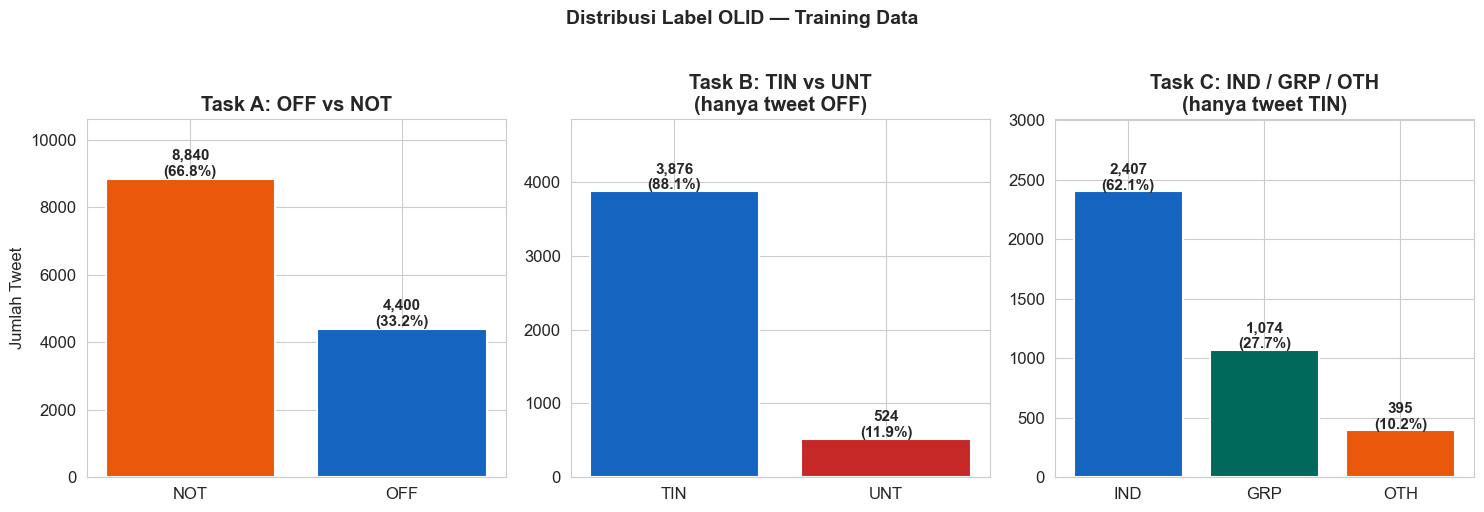

💾 Grafik disimpan ke output/distribusi_label.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Label OLID — Training Data', fontsize=14, fontweight='bold', y=1.02)

# ── Task A ──
cnt_a = train['subtask_a'].value_counts()
colors_a = ['#EA580C', '#1565C0']
axes[0].bar(cnt_a.index, cnt_a.values, color=colors_a, edgecolor='white', linewidth=1.5)
axes[0].set_title('Task A: OFF vs NOT', fontweight='bold')
axes[0].set_ylabel('Jumlah Tweet')
for i, (lbl, val) in enumerate(cnt_a.items()):
    axes[0].text(i, val + 80, f'{val:,}\n({val/len(train)*100:.1f}%)', 
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, cnt_a.max() * 1.2)

# ── Task B ──
cnt_b = train['subtask_b'].dropna().value_counts()
colors_b = ['#1565C0', '#C62828']
axes[1].bar(cnt_b.index, cnt_b.values, color=colors_b, edgecolor='white', linewidth=1.5)
axes[1].set_title('Task B: TIN vs UNT\n(hanya tweet OFF)', fontweight='bold')
for i, (lbl, val) in enumerate(cnt_b.items()):
    axes[1].text(i, val + 20, f'{val:,}\n({val/cnt_b.sum()*100:.1f}%)', 
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, cnt_b.max() * 1.25)

# ── Task C ──
cnt_c = train['subtask_c'].dropna().value_counts()
colors_c = ['#1565C0', '#00695C', '#EA580C']
axes[2].bar(cnt_c.index, cnt_c.values, color=colors_c, edgecolor='white', linewidth=1.5)
axes[2].set_title('Task C: IND / GRP / OTH\n(hanya tweet TIN)', fontweight='bold')
for i, (lbl, val) in enumerate(cnt_c.items()):
    axes[2].text(i, val + 10, f'{val:,}\n({val/cnt_c.sum()*100:.1f}%)', 
                 ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylim(0, cnt_c.max() * 1.25)

plt.tight_layout()
plt.savefig('../output/distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Grafik disimpan ke output/distribusi_label.png')

In [10]:
# Ringkasan distribusi dalam bentuk tabel
print('=== RINGKASAN DISTRIBUSI LABEL ===')
print('\nTask A (Training):')
print(train['subtask_a'].value_counts().to_frame('count').assign(persen=lambda x: (x['count']/x['count'].sum()*100).round(1)))
print('\nTask B (Training - hanya OFF):')
print(train['subtask_b'].dropna().value_counts().to_frame('count').assign(persen=lambda x: (x['count']/x['count'].sum()*100).round(1)))
print('\nTask C (Training - hanya TIN):')
print(train['subtask_c'].dropna().value_counts().to_frame('count').assign(persen=lambda x: (x['count']/x['count'].sum()*100).round(1)))



=== RINGKASAN DISTRIBUSI LABEL ===

Task A (Training):
           count  persen
subtask_a               
NOT         8840    66.8
OFF         4400    33.2

Task B (Training - hanya OFF):
           count  persen
subtask_b               
TIN         3876    88.1
UNT          524    11.9

Task C (Training - hanya TIN):
           count  persen
subtask_c               
IND         2407    62.1
GRP         1074    27.7
OTH          395    10.2


Kesimpulan:
   - Task A: NOT lebih banyak 2x lipat dari OFF → imbalance sedang
   - Task B: TIN mendominasi 88% → imbalance BERAT (butuh weighted loss!)
   - Task C: OTH hanya 10% → imbalance sedang-berat

---
## STEP 5 — Analisis Panjang Tweet

Panjang tweet penting untuk menentukan `max_length` pada tokenisasi.

/var/folders/80/2gxv0thx6hl4n28tpz0m8d340000gn/T/ipykernel_1223/3079091542.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([not_len, off_len], labels=['NOT', 'OFF'], patch_artist=True,


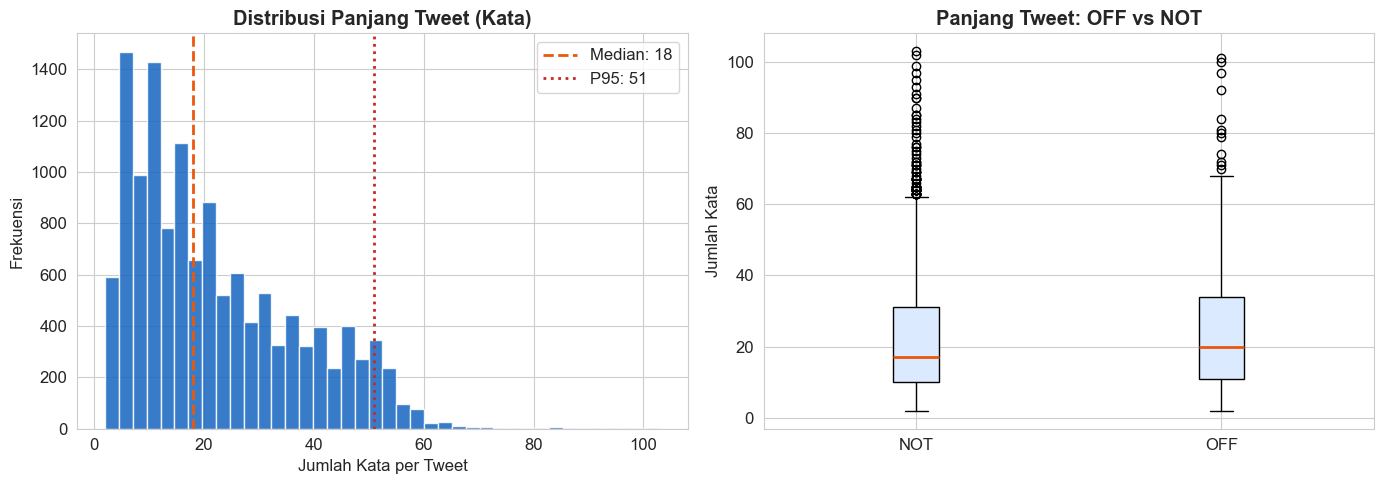

Statistik panjang tweet (kata):
  Min    : 2
  Median : 18
  Mean   : 22.3
  Max    : 103
  P95    : 51


In [12]:
# Hitung panjang tweet dalam kata
train['n_kata'] = train['tweet'].apply(lambda x: len(str(x).split()))
train['n_char'] = train['tweet'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi jumlah kata
axes[0].hist(train['n_kata'], bins=40, color='#1565C0', edgecolor='white', alpha=0.85)
axes[0].axvline(train['n_kata'].median(), color='#EA580C', lw=2, linestyle='--', label=f'Median: {train["n_kata"].median():.0f}')
axes[0].axvline(train['n_kata'].quantile(0.95), color='#C62828', lw=2, linestyle=':', label=f'P95: {train["n_kata"].quantile(0.95):.0f}')
axes[0].set_xlabel('Jumlah Kata per Tweet')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi Panjang Tweet (Kata)', fontweight='bold')
axes[0].legend()

# Boxplot per label Task A
off_len = train[train['subtask_a']=='OFF']['n_kata']
not_len = train[train['subtask_a']=='NOT']['n_kata']
axes[1].boxplot([not_len, off_len], labels=['NOT', 'OFF'], patch_artist=True,
                boxprops=dict(facecolor='#DBEAFE'),
                medianprops=dict(color='#EA580C', linewidth=2))
axes[1].set_ylabel('Jumlah Kata')
axes[1].set_title('Panjang Tweet: OFF vs NOT', fontweight='bold')

plt.tight_layout()
plt.savefig('../output/panjang_tweet.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Statistik panjang tweet (kata):')
print(f'  Min    : {train["n_kata"].min()}')
print(f'  Median : {train["n_kata"].median():.0f}')
print(f'  Mean   : {train["n_kata"].mean():.1f}')
print(f'  Max    : {train["n_kata"].max()}')
print(f'  P95    : {train["n_kata"].quantile(0.95):.0f}')


✅ max_length=128 token sudah lebih dari cukup (P95 = 51 kata)

Hampir semua data (95%) hanya butuh sekitar 68 token
Token diberikan "128" → hampir 2x lebih besar dari kebutuhan mayoritas
	Jadi: efisien, jarang kena truncation (kepotong)

---
## STEP 6 — Kata-Kata Paling Umum per Label

Melihat kata apa yang sering muncul di tweet OFF vs NOT membantu memahami pola bahasa ofensif.

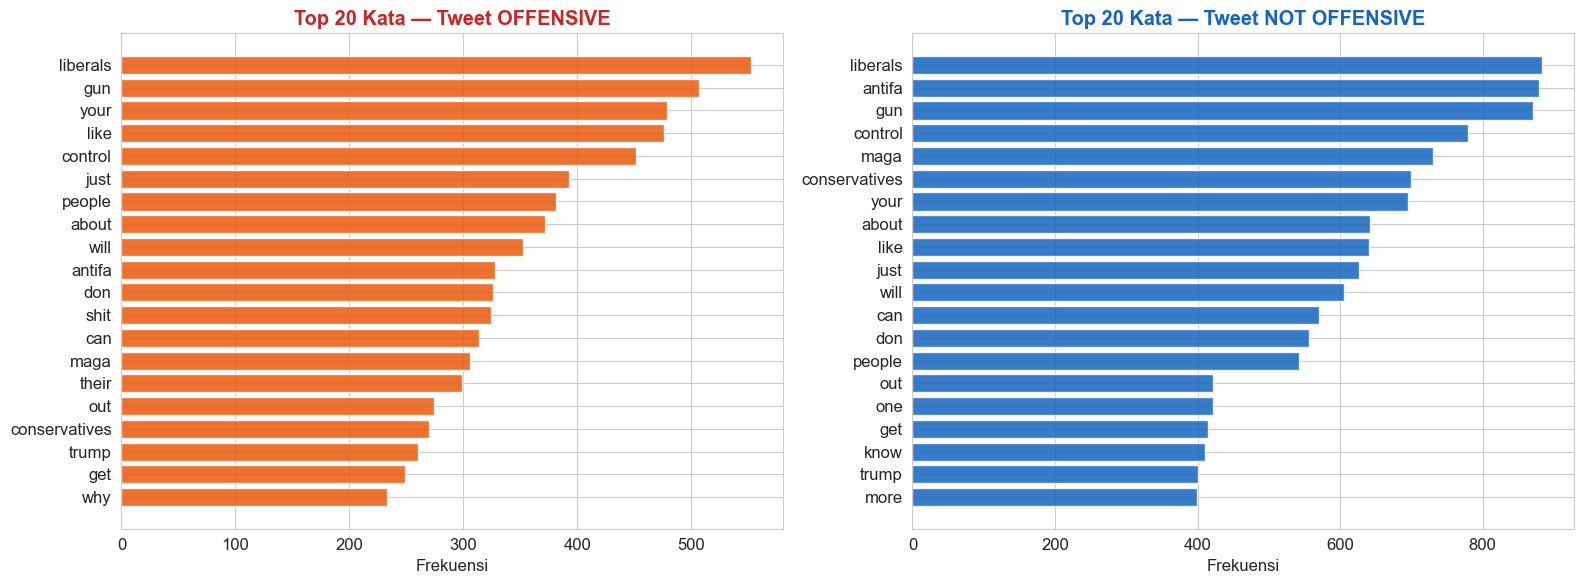

In [13]:
import re
from collections import Counter

# Stopwords sederhana
STOPWORDS = set(['the','a','an','is','it','to','of','and','in','that','for',
                  'this','are','was','with','his','her','he','she','they','we',
                  'you','i','be','at','by','on','as','if','or','so','do','not',
                  'have','has','had','but','from','what','who','how','all',
                  'user','rt','amp','url','http','https'])

def get_top_words(texts, n=20):
    words = []
    for t in texts:
        t = re.sub(r'http\S+|@\w+|#', '', str(t).lower())
        words += [w for w in re.findall(r'\b[a-z]{3,}\b', t) if w not in STOPWORDS]
    return Counter(words).most_common(n)

top_off = get_top_words(train[train['subtask_a']=='OFF']['tweet'])
top_not = get_top_words(train[train['subtask_a']=='NOT']['tweet'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

words_off, cnt_off = zip(*top_off)
axes[0].barh(words_off[::-1], cnt_off[::-1], color='#EA580C', alpha=0.85)
axes[0].set_title('Top 20 Kata — Tweet OFFENSIVE', fontweight='bold', color='#C62828')
axes[0].set_xlabel('Frekuensi')

words_not, cnt_not = zip(*top_not)
axes[1].barh(words_not[::-1], cnt_not[::-1], color='#1565C0', alpha=0.85)
axes[1].set_title('Top 20 Kata — Tweet NOT OFFENSIVE', fontweight='bold', color='#1565C0')
axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig('../output/top_kata.png', dpi=150, bbox_inches='tight')
plt.show()

Grafik menunjukkan distribusi kata yang paling sering muncul pada tweet OFFENSIVE dan NOT OFFENSIVE. Terlihat bahwa banyak kata seperti “liberals”, “gun”, dan “control” muncul di kedua kelas, yang mengindikasikan bahwa topik utama dataset bersifat politis. Namun, pada kelas OFFENSIVE terdapat kata-kata dengan nuansa lebih kasar seperti “shit”, yang mencerminkan penggunaan bahasa yang lebih agresif. Sebaliknya, kelas NOT OFFENSIVE cenderung mengandung kata yang lebih netral dan informatif seperti “about” dan “know”. Hal ini menunjukkan bahwa perbedaan utama antara kedua kelas tidak hanya terletak pada kata tunggal, tetapi juga pada konteks penggunaan kata tersebut.

---
## STEP 7 — Distribusi Test Set

menggambarkan distribusi label pada data test (yang digunakan untuk evaluasi akhir).

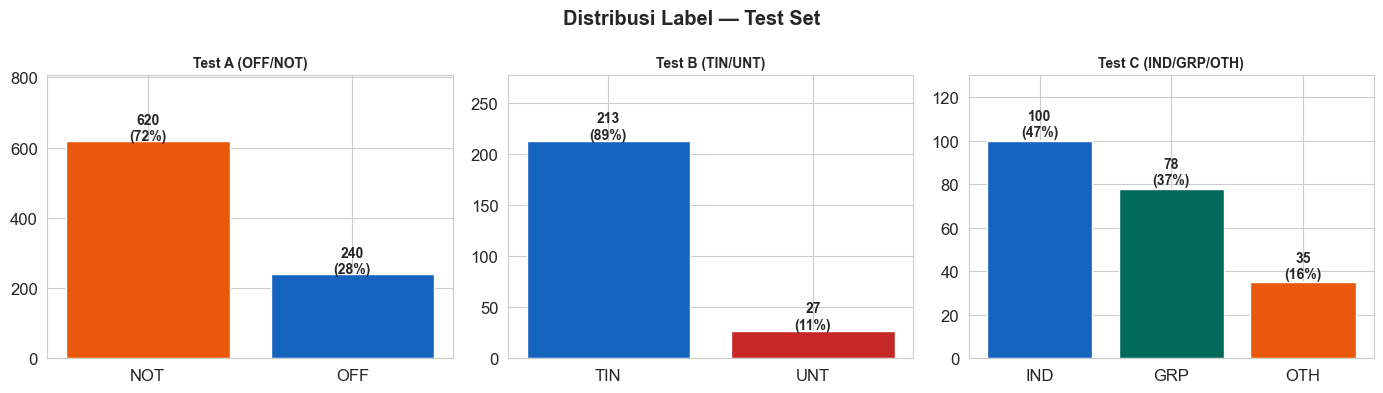

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribusi Label — Test Set', fontweight='bold')

for ax, df, title, colors in [
    (axes[0], test_a, 'Test A (OFF/NOT)', ['#EA580C','#1565C0']),
    (axes[1], test_b, 'Test B (TIN/UNT)', ['#1565C0','#C62828']),
    (axes[2], test_c, 'Test C (IND/GRP/OTH)', ['#1565C0','#00695C','#EA580C']),
]:
    cnt = df['label'].value_counts()
    ax.bar(cnt.index, cnt.values, color=colors[:len(cnt)], edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    for i, (lbl, val) in enumerate(cnt.items()):
        ax.text(i, val + 2, f'{val}\n({val/cnt.sum()*100:.0f}%)',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, cnt.max() * 1.3)

plt.tight_layout()
plt.savefig('../output/distribusi_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## STEP 8 — Ringkasan & Kesimpulan Eksplorasi

Sebelum lanjut ke notebook fine-tuning, ini yang perlu diingat:

In [16]:
print('=' * 60)
print('RINGKASAN EKSPLORASI DATASET OLID')
print('=' * 60)

print('\n📦 Ukuran Dataset:')
print(f'   Training  : {len(train):,} tweet')
print(f'   Test A    : {len(test_a)} tweet')
print(f'   Test B    : {len(test_b)} tweet')
print(f'   Test C    : {len(test_c)} tweet')

off_count = (train['subtask_a']=='OFF').sum()
not_count = (train['subtask_a']=='NOT').sum()
tin_count = (train['subtask_b']=='TIN').sum()
unt_count = (train['subtask_b']=='UNT').sum()

print('\n⚖️  Class Imbalance:')
print(f'   Task A — NOT: {not_count} ({not_count/len(train)*100:.1f}%) | OFF: {off_count} ({off_count/len(train)*100:.1f}%)')
print(f'   Task B — TIN: {tin_count} ({tin_count/(tin_count+unt_count)*100:.1f}%) | UNT: {unt_count} ({unt_count/(tin_count+unt_count)*100:.1f}%)')

print('\n📏 Panjang Tweet:')
print(f'   Rata-rata : {train["n_kata"].mean():.1f} kata')
print(f'   Maksimum  : {train["n_kata"].max()} kata')
print(f'   P95       : {train["n_kata"].quantile(0.95):.0f} kata')


RINGKASAN EKSPLORASI DATASET OLID

📦 Ukuran Dataset:
   Training  : 13,240 tweet
   Test A    : 860 tweet
   Test B    : 240 tweet
   Test C    : 213 tweet

⚖️  Class Imbalance:
   Task A — NOT: 8840 (66.8%) | OFF: 4400 (33.2%)
   Task B — TIN: 3876 (88.1%) | UNT: 524 (11.9%)

📏 Panjang Tweet:
   Rata-rata : 22.3 kata
   Maksimum  : 103 kata
   P95       : 51 kata


🔑 Keputusan Desain (berdasarkan eksplorasi):
   ✅ max_length = 128  (cukup untuk 95% tweet)
   ✅ Weighted loss WAJIB untuk Task B (TIN 88% vs UNT 12%)
   ✅ Macro F1 sebagai metrik utama (bukan Accuracy)
   ✅ Evaluation: Independent + Cascaded